In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
url = "https://huggingface.co/datasets/arti199919/synthetic-saas-churn-sample/resolve/main/user_monthly.parquet"

df = pd.read_parquet(url)
df.shape

(79817, 15)

In [4]:
df.sample(5)

,user_id,month,tenure_month,plan_type,monthly_price,mrr,sessions,feature_usage_score,support_tickets,payment_failures,churned,churned_next_month,nps_score,product_incident,active_seats
22258,U0001400,2025-08-01,17,Starter,78.816666,78.816666,26,43.373196,1,0,0,0,6,0,4
6631,U0000426,2024-04-01,3,Starter,64.498627,64.498627,20,60.164341,1,0,0,0,5,0,2
73026,U0004576,2025-11-01,17,Starter,52.167439,52.167439,26,65.223244,1,0,0,0,6,0,1
41947,U0002624,2025-03-01,14,Pro,161.733459,161.733459,31,82.172333,1,0,0,0,7,0,4
614,U0000039,2025-12-01,14,Starter,74.368301,74.368301,33,82.213974,0,0,0,0,10,0,5


In [5]:
df.shape

(79817, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79817 entries, 0 to 79816
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              79817 non-null  object        
 1   month                79817 non-null  datetime64[ns]
 2   tenure_month         79817 non-null  int16         
 3   plan_type            79817 non-null  category      
 4   monthly_price        79817 non-null  float32       
 5   mrr                  79817 non-null  float32       
 6   sessions             79817 non-null  int32         
 7   feature_usage_score  79817 non-null  float32       
 8   support_tickets      79817 non-null  int16         
 9   payment_failures     79817 non-null  int16         
 10  churned              79817 non-null  int8          
 11  churned_next_month   79817 non-null  int8          
 12  nps_score            79817 non-null  int16         
 13  product_incident     79817 non-

In [7]:
print(df.describe())

                               month  tenure_month  monthly_price  \
count                          79817  79817.000000   79817.000000   
mean   2025-02-22 16:08:02.423544064      8.426764     255.184708   
min              2024-01-01 00:00:00      0.000000      36.779137   
25%              2024-10-01 00:00:00      4.000000      64.635986   
50%              2025-03-01 00:00:00      8.000000     162.130081   
75%              2025-08-01 00:00:00     13.000000     302.122345   
max              2025-12-01 00:00:00     23.000000    3834.952637   
std                              NaN      5.713899     329.402954   

                mrr      sessions  feature_usage_score  support_tickets  \
count  79817.000000  79817.000000         79817.000000     79817.000000   
mean     255.184708     29.603230            46.497925         1.104213   
min       36.779137      0.000000             0.000000         0.000000   
25%       64.635986     17.000000            30.943348         0.000000   
50%

In [8]:
df.duplicated().sum()

np.int64(0)

<Axes: >

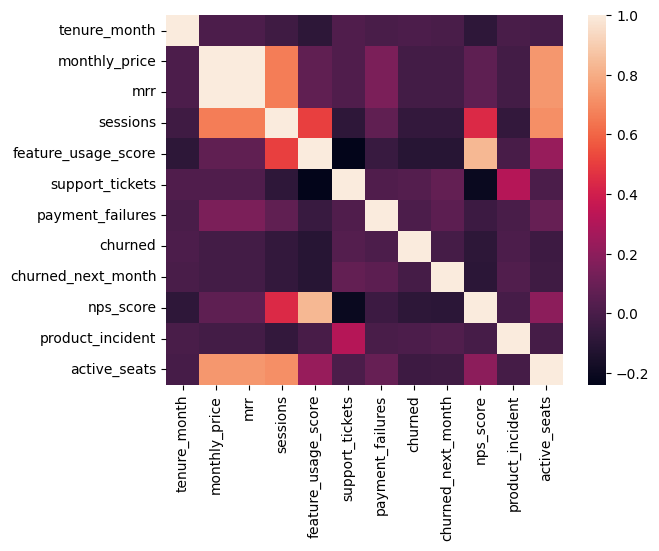

In [9]:
sns.heatmap(df.corr(numeric_only=True))

In [10]:
df.columns

Index(['user_id', 'month', 'tenure_month', 'plan_type', 'monthly_price', 'mrr',
       'sessions', 'feature_usage_score', 'support_tickets',
       'payment_failures', 'churned', 'churned_next_month', 'nps_score',
       'product_incident', 'active_seats'],
      dtype='object')

In [11]:
for col in df.columns:
  print(f"{col}: {df[col].nunique()}")
  print(df[col].unique())

user_id: 5000
['U0000001' 'U0000002' 'U0000003' ... 'U0004998' 'U0004999' 'U0005000']
month: 24
<DatetimeArray>
['2024-11-01 00:00:00', '2024-12-01 00:00:00', '2025-01-01 00:00:00',
 '2025-02-01 00:00:00', '2025-03-01 00:00:00', '2025-04-01 00:00:00',
 '2025-05-01 00:00:00', '2025-06-01 00:00:00', '2025-07-01 00:00:00',
 '2025-08-01 00:00:00', '2025-09-01 00:00:00', '2025-10-01 00:00:00',
 '2025-11-01 00:00:00', '2025-12-01 00:00:00', '2024-02-01 00:00:00',
 '2024-03-01 00:00:00', '2024-04-01 00:00:00', '2024-05-01 00:00:00',
 '2024-06-01 00:00:00', '2024-07-01 00:00:00', '2024-08-01 00:00:00',
 '2024-09-01 00:00:00', '2024-10-01 00:00:00', '2024-01-01 00:00:00']
Length: 24, dtype: datetime64[ns]
tenure_month: 24
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
plan_type: 4
['Starter', 'Business', 'Pro', 'Enterprise']
Categories (4, object): ['Business', 'Enterprise', 'Pro', 'Starter']
monthly_price: 5000
[ 80.30978   67.729385  51.607925 ... 439.3574   175.081

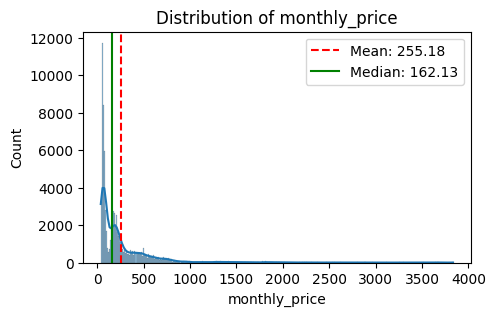

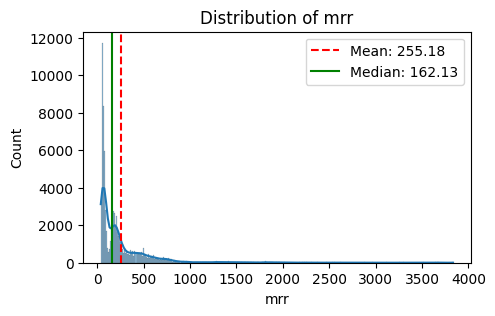

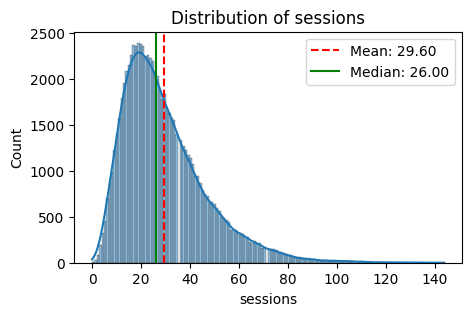

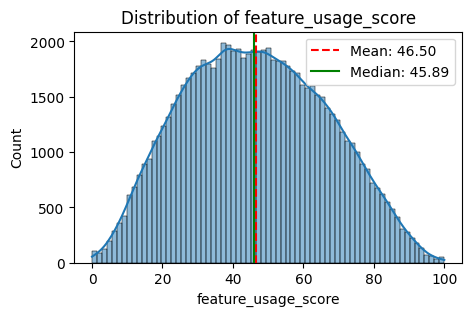

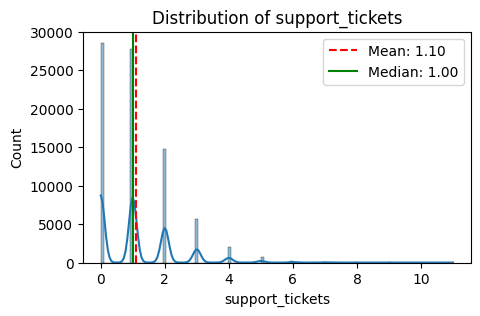

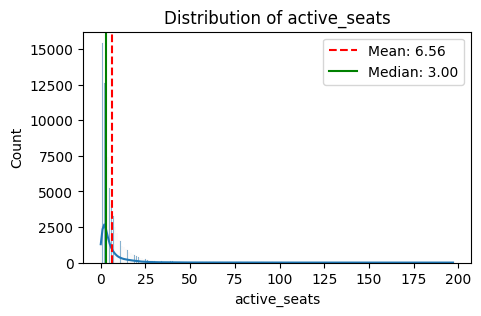

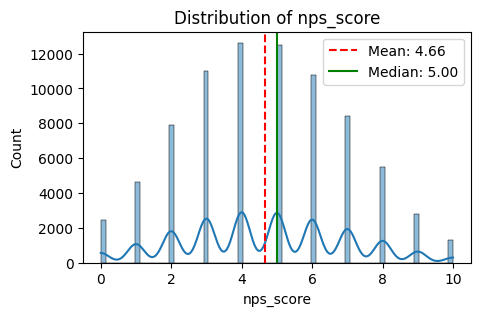

In [13]:
def plot_histogram(df, column):
  plt.figure(figsize=(5, 3))
  sns.histplot(df[column], kde=True)
  plt.title(f"Distribution of {column}")
  col_mean = df[column].mean()
  col_median = df[column].median()

  plt.axvline(col_mean, color='r', linestyle='--', label=f'Mean: {col_mean:.2f}')
  plt.axvline(col_median, color='g', linestyle='-', label=f'Median: {col_median:.2f}')
  plt.legend()
  plt.show()

numeric = ['monthly_price', 'mrr', 'sessions', 'feature_usage_score', 'support_tickets', 'active_seats', 'nps_score']
for col in numeric:
  plot_histogram(df, col)

In [16]:
#Leakage audit — verify churned_next_month is literally churned shifted by one row per customer
df = df.sort_values(['user_id', 'month'])
df['churned_shifted'] = df.groupby('user_id')['churned'].shift(-1)
match_rate = (df['churned_next_month'] == df['churned_shifted']).mean()
print(match_rate)

0.9373567034591629


In [18]:
# isolate rows where a real next-month value exists (i.e. not the customer's last row)
valid = df.dropna(subset=['churned_shifted'])
match_rate_valid = (valid['churned_next_month'] == valid['churned_shifted']).mean()
print(match_rate_valid)
print(len(df) - len(valid), "rows dropped (last row per customer)")

1.0
5000 rows dropped (last row per customer)


In [21]:
# checking for the difference
last_rows = df.groupby('user_id').tail(1)
print(last_rows['churned_next_month'].value_counts(dropna=False))

churned_next_month
0    5000
Name: count, dtype: int64


In [22]:
df = df.drop(columns=['churned_next_month'])

In [23]:
# 1. Overall churn rate
overall_rate = df['churned'].mean()
print(f"Overall churn rate: {overall_rate:.4%}")

# 2. Churn rate by month (drift check)
monthly_rate = df.groupby('month')['churned'].mean()
print(monthly_rate)

# 3. Churn rate by plan type (quick look)
plan_rate = df.groupby('plan_type')['churned'].mean()
print(plan_rate)

Overall churn rate: 1.4170%
month
2024-01-01    0.025641
2024-02-01    0.017287
2024-03-01    0.021108
2024-04-01    0.015344
2024-05-01    0.012541
2024-06-01    0.017655
2024-07-01    0.011905
2024-08-01    0.008236
2024-09-01    0.011927
2024-10-01    0.015202
2024-11-01    0.013661
2024-12-01    0.011905
2025-01-01    0.014085
2025-02-01    0.011868
2025-03-01    0.011343
2025-04-01    0.013723
2025-05-01    0.010493
2025-06-01    0.016598
2025-07-01    0.013361
2025-08-01    0.017581
2025-09-01    0.016203
2025-10-01    0.016716
2025-11-01    0.017250
2025-12-01    0.015772
Name: churned, dtype: float64
plan_type
Business      0.009095
Enterprise    0.013414
Pro           0.012322
Starter       0.017561
Name: churned, dtype: float64


/tmp/ipykernel_5143/2562927694.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plan_rate = df.groupby('plan_type')['churned'].mean()


In [25]:
# is Jan 2024 just "everyone's first row"?
first_months = df.groupby('user_id')['month'].min()
print(first_months.value_counts().sort_index().head())

month
2024-01-01    390
2024-02-01    372
2024-03-01    398
2024-04-01    386
2024-05-01    358
Name: count, dtype: int64


In [26]:
# candidate cutoffs: last 2, 3, 4 months as test
for n_months in [2, 3, 4]:
    cutoff = df['month'].max() - pd.DateOffset(months=n_months - 1)
    test = df[df['month'] >= cutoff]
    train = df[df['month'] < cutoff]
    print(f"Last {n_months} months as test (cutoff={cutoff.date()}):")
    print(f"  train rows={len(train)}, test rows={len(test)}")
    print(f"  train churners={train['churned'].sum()}, test churners={test['churned'].sum()}")
    print()

Last 2 months as test (cutoff=2025-11-01):
  train rows=71886, test rows=7931
  train churners=1000, test churners=131

Last 3 months as test (cutoff=2025-10-01):
  train rows=67818, test rows=11999
  train churners=932, test churners=199

Last 4 months as test (cutoff=2025-09-01):
  train rows=63683, test rows=16134
  train churners=865, test churners=266



In [27]:
cutoff = pd.Timestamp('2025-10-01')
train_df = df[df['month'] < cutoff].copy()
test_df = df[df['month'] >= cutoff].copy()

print(f"Train: {len(train_df)} rows, {train_df['churned'].sum()} churners ({train_df['churned'].mean():.4%})")
print(f"Test:  {len(test_df)} rows, {test_df['churned'].sum()} churners ({test_df['churned'].mean():.4%})")

Train: 67818 rows, 932 churners (1.3743%)
Test:  11999 rows, 199 churners (1.6585%)


In [28]:
# For each churned customer, find their churn month
churn_month = df[df['churned'] == 1].groupby('user_id')['month'].min().rename('churn_month')

# Merge back onto full panel, only for customers who eventually churn
churners = df[df['user_id'].isin(churn_month.index)].merge(churn_month, on='user_id')

# Compute "months before churn" for each row
churners['months_before_churn'] = (
    (churners['churn_month'].dt.year - churners['month'].dt.year) * 12 +
    (churners['churn_month'].dt.month - churners['month'].dt.month)
)

# Keep only the 6 months leading up to churn (0 = churn month itself)
window = churners[(churners['months_before_churn'] >= 0) & (churners['months_before_churn'] <= 6)]

# Average engagement metric at each distance from churn
trend = window.groupby('months_before_churn')[['sessions', 'feature_usage_score']].mean().sort_index(ascending=False)
print(trend)

                      sessions  feature_usage_score
months_before_churn                                
6                    20.412011            31.058050
5                    20.646214            30.795195
4                    19.996399            30.335253
3                    19.747497            29.135506
2                    19.579055            28.684999
1                    19.143939            27.386467
0                    19.157383            27.658661


In [29]:
non_churners = df[~df['user_id'].isin(churn_month.index)]
baseline = non_churners.groupby('month')[['sessions', 'feature_usage_score']].mean()
print(baseline.tail(6))

             sessions  feature_usage_score
month                                     
2025-07-01  30.203153            46.891212
2025-08-01  30.098217            46.414345
2025-09-01  29.812096            45.728992
2025-10-01  29.670457            45.325241
2025-11-01  29.421814            44.753933
2025-12-01  28.976738            44.085300


In [30]:
# per-month population average (all customers, that specific month)
pop_avg = df.groupby('month')[['sessions', 'feature_usage_score']].transform('mean')
df['sessions_vs_pop'] = df['sessions'] - pop_avg['sessions']
df['usage_vs_pop'] = df['feature_usage_score'] - pop_avg['feature_usage_score']

# redo the churner trend, now relative to that month's population average
churners2 = df[df['user_id'].isin(churn_month.index)].merge(churn_month, on='user_id')
churners2['months_before_churn'] = (
    (churners2['churn_month'].dt.year - churners2['month'].dt.year) * 12 +
    (churners2['churn_month'].dt.month - churners2['month'].dt.month)
)
window2 = churners2[(churners2['months_before_churn'] >= 0) & (churners2['months_before_churn'] <= 6)]
print(window2.groupby('months_before_churn')[['sessions_vs_pop', 'usage_vs_pop']].mean().sort_index(ascending=False))

                     sessions_vs_pop  usage_vs_pop
months_before_churn                               
6                          -9.364329    -16.163788
5                          -9.073988    -16.232019
4                          -9.686258    -16.546152
3                          -9.908472    -17.603106
2                         -10.058173    -17.929016
1                         -10.460493    -19.124392
0                         -10.415696    -18.730366
